# Zadanie 1

W tym ćwiczeniu poznamy trzy nowe reprezentacje genetyczne, a potem pomożemy ewolucji wydostać się z plateau krajobrazu przystosowania.

Poprzednio poznaliśmy prostą i bardzo ograniczoną reprezentację genetyczną f9. Teraz pora na f0, f1 i f4.

- Uruchom GUI Framsticks.exe.
- Zaczniemy od f1, która jest domyślną reprezentacją, dlatego nie trzeba w genotypach podawać prefiksu formatu
 /\*1\*/
- Kliknij na przycisk "New" do wprowadzania nowego genotypu Eksperymentując z różnymi genotypami, poznaj znaczenie genów: *X*, nawiasy *(* i *)*, przecinek *,*, geny-modyfikatory: duże i małe *R*, duże i małe *Q*, duże i małe *C*, duże *i*, małe *L*.
Podczas edycji czasem zobaczysz, że tło zmienia się na kolor różowy lub czerwony, i podkreślony jest gen stanowiący początek problematycznej sekwencji. Jeśli tło jest różowe, to znaczy, że operatory naprawy potrafią przekształcić niepoprawny genotyp w poprawny – na przykład dodając lub usuwając nawiasy (i wtedy to, co widzisz na podglądzie struktury, odpowiada wersji naprawionej genotypu, której nie widzisz). Jeśli tło jest czerwone, to znaczy, że genotyp jest niepoprawny i operatory naprawy nie potrafią go naprawić.
- Stwórz w f1 genotyp odpowiadający  temu kształtowi.
- Stwórz w f1 genotyp odpowiadający kwadratowi (ma tak wyglądać, ale krańce nie są połączone. Użyj tylko Xów, nawiasów i przecinków).
- Na tych zajęciach nie będziemy zajmowali się siecią neuronową.
- Wypróbuj teraz edycję kilku prostych genotypów f4. Jest ona w pewnym sensie zbliżona do f1 (posiada symbol X oraz
te same geny-modfikatory RQCL), ale koduje proces rozwoju fenotypu. Zaczynamy od jednej niezróżnicowanej komórki, gen *<* oznacza zawsze podział na dwie komórki, a gen *>* oznacza koniec rozwoju komórki czyli jej specjalizację do stick'a *X* albo do neuronu, np. *N:N*. Dodatkowo gen *#* pozwala powtarzać interpretację danego fragmentu genotypu (pobaw się modyfikując np. 
*/\*4\*/rr#5,<<X><<RRX>X>X>>LLX)*.
- Poeksperymentuj próbując wpisać kilka poprawnych genotypów f4.
- Wreszcie pora na f0. To jest najbardziej niskopoziomowe kodowanie genetyczne, gdzie każda linijka opisuje pewien element fenotypu. Linijki zaczynające się od 
*p:* to "Parts" (i trzy kolejne wartości to współrzędne x,y,z), a linijki zaczynające się od *j:* to połączenia między Parts, czyli "Joints" (i dwie kolejne wartości to indeksy łączonych Parts).  Wartości domyślne (najczęściej zera) mogą być pomijane.
- Wszystkie genotypy we wszystkich reprezentacjach genetycznych we Framsticks muszą być przetłumaczalne do f0, żeby odpowiadające im fenotypy mogły być symulowane. Mając otwarte okienko edycji dowolnego genotypu (np. jakiś prosty genotyp f9 z poprzedniego laboratorium), kliknij w tym okienku po lewej na pozycję "Conversions" – i znajdziesz tam genotyp f0 odpowiadający (równoważny) temu edytowanemu. Zatem aby stworzyć nową reprezentację genetyczną, wystarczy dostarczyć procedurę translacji do dowolnej istniejącej reprezentacji, w ten sposób tworząc nowy węzeł w drzewie konwersji reprezentacji.
- Wedle drzewa Gregory Hornby'ego klasyfikującego różne embriogenezy (otwórz sobie pdf ostatniego wykładu 
tego o projektowaniu ewolucyjnym), gdzie w tym drzewie powinny się znaleźć f0, f1, f4, f9, a także mapowanie genotyp-fenotyp dla permutacji, gdy rozwiązujemy np. problem TSP?

W odpowiedzi zaklasyfikuj pięć reprezentacji i mapowań (f0, f1, f4, f9, permutacja) oraz wklej genotypy f1 kwadratu oraz tej kolczatej konstrukcji.

Klasyfikacja Hornby'ego:
- f0: Open ended → Nongenerative → Direct (geny *p* i *j* tworzą bezpośredni plan budowy)
- f1: Open ended → Nongenerative → Direct (geny nadal tworzą drzewo instrukcji - topologię (które pręty są połączone z którymi) i modyfikatory orientacji)
- f4: Open ended → Generative → Explicit (geny mogą być aktywowane wielokrotnie - rekursja/iteracja - podczas procesu rozwoju)
- f9: Open ended → Nongenerative → Direct (geny tworzą bezpośredni plan budowy)
- permutacja w TSP i QAP: Parametrizations (genotyp to bezpośrednia permutacja elementów - lista o określonej długości)

Genotypy f1:
- Kwadrat: X(,,X(,,X(,,X)))
- Kolczata konstrukcja: X(X,rrX(X,rrX(X,rrX(X,X,X),X),X),X)

# Zadanie 2

- Przeprowadź teraz eksperymenty takie same jak na poprzednich laboratoriach (czyli też kryterium wysokości środka ciężkości "vertpos"), ale tym razem testując cztery reprezentacje genetyczne i zaczynając od najprostszego genotypu w każdej z tych reprezentacji (najczęściej jest to "Stick" czyli dwa Party połączone Jointem). Pętla realizująca taki eksperyment może wyglądać tak (zwróć uwagę na nowy plik `only-body.sim` i skopiuj go w odpowiednie miejsce, tak jak pozostałe pliki `*.sim`):
```bash
for %%F in (0,1,4,9) do (
    for /L %%N in (1,1,10) do (
        python FramsticksEvolution.py -path %DIR_WITH_FRAMS_LIBRARY%  -sim "eval
allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"  -opt vertpos -max_numparts 30   
genformat %%F   -popsize rozmiarconajmniej50    -generations odpowiedniadlugosc -hof_size 1 -hof_savefile
 HoF-f%%F-%%N.gen
    ))
```

In [ ]:
import subprocess
import sys
from pathlib import Path

def run_experiments(popsize=80, generations=150, modified=False):
    FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
    LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
    FS_SCRIPT = FRAMSPY_DIR / "FramsticksEvolution.py"

    sim_files = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"
    opt = "vertpos"
    max_numparts = "30"
    hof_size = "1"

    initial_genotypes = {
        0: "//0\np:0,0,0\np:1,0,0\np:2,0,0\nj:0,1,dx=1.0,0.0,0.0\nj:1,2,dx=1.0,0.0,0.0",
        1: "/*1*/XX",
        4: "/*4*/<X>X",
        9: "/*9*/UU",
    }

    out_dir = FRAMSPY_DIR / "results" / "modified_fitness"
    hof_dir = out_dir / "HallOfFame"
    out_dir.mkdir(parents=True, exist_ok=True)
    hof_dir.mkdir(parents=True, exist_ok=True)

    for F in (0, 1, 4, 9):
        for N in range(1, 11):
            init = initial_genotypes[F]

            suffix = "-modified-fitness" if modified else ""

            hof_file = hof_dir / f"HoF-genotype{suffix}-f{F}-{N}.gen"
            args = [
                sys.executable,
                str(FS_SCRIPT),
                "-path", LIB_DIR,
                "-sim", sim_files,
                "-opt", opt,
                "-max_numparts", max_numparts,
                "-genformat", str(F),
                "-initialgenotype", init,
                "-popsize", str(popsize),
                "-generations", str(generations),
                "-hof_size", hof_size,
                "-hof_savefile", str(hof_file)
            ]

            result_file = out_dir / f"results-genotype{suffix}-f{F}-{N}.txt"

            with result_file.open("w", encoding="utf-8") as fout:
                try:
                    subprocess.run(args, cwd=str(FRAMSPY_DIR), stdout=fout, stderr=subprocess.STDOUT, check=True)
                except subprocess.CalledProcessError as e:
                    print(f"  -> process exited with code {e.returncode}. See {result_file.name} for details.")
                except Exception as e:
                    print(f"  -> unexpected error: {e}")

In [2]:
run_experiments()

- Wygeneruj trzy rodzaje wykresów tak jak poprzednio (na każdym cztery kategorie odpowiadające czterem reprezentacjom genetycznym). Jak widzisz, ewolucja na początku utyka w pewnym trudnym obszarze (małe ujemne wartości wysokości środka ciężkości konstrukcji możesz traktować jako delikatne wgniatanie się płaskiej konstrukcji w miękkie podłoże). Postarajmy się pomóc ewolucji wyjść z tego trudnego obszaru samodzielnie, tzn. nie podając jej od razu genotypu konstrukcji która już jest wysoka (tak zrobiliśmy na poprzednim laboratorium), ale zmieniając funkcję celu w minimalnym zakresie, jaki jest wymagany, żeby wydostać się z płaskiego obszaru krajobrazu.
- Przeanalizuj funkcję `frams_evaluate()` w pliku `FramsticksEvolution.py`. W zmiennej `default_evaluation_data` masz słownik różnych kryteriów oceny genotypu, z którego wybierane są tylko kryteria faktycznie używane w ewolucji (`OPTIMIZATION_CRITERIA`). Wyświetl zawartość zmiennej `default_evaluation_data` wewnątrz funkcji `frams_evaluate()` dla kilku genotypów płaskich (`vertpos<=0`) i nie-płaskich (`vertpos>0`) osobników. Czy krajobraz przystosowania dla `vertpos<0` jest idealnie płaski (rozwiązania mają dokładnie taką samą ocenę – tzn. całkowity brak gradientu), czy też występują na nim malutkie nierówności?
- Wiesz już, czym są "numparts" i "numjoints" w ocenianej konstrukcji. Oprócz tego w słowniku jest "lifespan" (liczba kroków symulacji – zapewne taka sama dla wszystkich ocenianych konstrukcji), "distance" oraz "velocity" (przy czym velocity=distance/lifespan, ale `only-body.sim` wyłącza budowanie sieci neuronowej, więc zmierzona odległość jest drobnym przypadkowym "błędem pomiaru"). Używając dostępnych w słowniku kryteriów wymyśl, jak zmodyfikować formułę na fitness, żeby w jak najmniejszym obszarze krajobrazu przystosowania zmodyfikować go tak, żeby wyprowadzić ewolucję z plateau tworząc gradient. Wprowadź zmiany oraz powtórz cały eksperyment obliczeniowy, wytwarzając w ten sposób cztery kolejne kategorie na wykresach.
- Przemyśl dokładnie swoją modyfikację pod kątem efektów ubocznych. Często pierwszy pomysł – pomimo tego, że szybciej wyprowadza populację z plateau – ma pewne wady. Wady – na przykład pomaga na początku ewolucji, ale wprowadza też niepotrzebny bias, którego chcemy unikać, albo jej wpływ jest niekontrolowany/niezamierzony, albo da się ulepszyć jej działanie. Dążymy do modyfikacji, o której autor może powiedzieć: działa lepiej, wiem dlaczego działa lepiej, osiągnąłem ten efekt intencjonalnie i potrafię go logicznie wyjaśnić oraz udowodnić na konkretnych przykładach ocen osobników. Nasza ingerencja powinna być minimalna oraz dobrze uzasadniona: działająca tylko w obszarze plateau i wystarczająca tylko do tego, żeby ewolucja jak najszybciej wydostała się z plateau korzystając z gradientu, nigdy nie modyfikująca jakości rozwiązań z plateau tak, by przewyższały surowe dodatnie wartości `vertpos` rozwiązań spoza plateau, w miarę możliwości nie wpływająca na charakter wyników w porównaniu do braku ingerencji.

W odpowiedzi:
- załącz trzy rodzaje wykresów (te same co na poprzednim laboratorium) z ośmioma kategoriami każdy (może być więcej niż osiem, jeśli prowadziłeś/aś więcej prób i testowałeś/aś więcej pomysłów),
- wyjaśnij dlaczego (przy ewolucji działającej z niezmodyfikowaną funkcją celu) populacja dla niektórych reprezentacji szybciej opuściła plateau, a dla innych potrzebowała większej liczby pokoleń?
- podaj dokładny, jednoznaczny opis i uzasadnienie swojej modyfikacji funkcji celu,
- zinterpretuj rezultaty eksperymentu,
- zastanów się i napisz, jakimi jeszcze metodami można pomóc ewolucji wyjść z plateau. Jedna z nich była użyta na poprzednim laboratorium – zaczęliśmy po prostu ewolucję daleko od plateau, ale to nie jest atrakcyjna metoda, bo wymaga wymyślenia rozwiązania i wprowadza nasz bias. Drugą ćwiczyliśmy teraz, i ta obecna metoda to też "ręczne sterowanie". A może istnieją bardziej naturalne metody, niż modyfikowanie funkcji celu – na przykład coś, co również pojawiło się na poprzednim laboratorium?

Zmieniłem funkcję celu w następujący sposób:
```python
vertpos = default_evaluation_data.get('vertpos', 0.0)
numparts = default_evaluation_data.get('numparts', 1)
max_numparts = 30
if vertpos < 0:
	plateau_fitness = - numparts / max_numparts
	fitness = [plateau_fitness]
else:
	fitness = [vertpos]
```
Dlatego przed wykonaniem kodu w następnej komórce należy dodać powyższy fragment kodu do funkcji `frams_evaluate()` w `FramsticksEvolution.py`.

In [2]:
run_experiments(modified=True)

In [ ]:
import os
import re
import pandas as pd
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
results_folder = FRAMSPY_DIR / "results" / "modified_fitness"

files = [f for f in os.listdir(results_folder) if f.startswith("results-genotype") and f.endswith(".txt")]

all_data = []
times_data = []

for file_name in files:
    path = results_folder / file_name

    modified_fitness = "modified-fitness" in file_name
    match = re.match(r"results-genotype(?:-modified-fitness)?-f(\d+)-(\d+)\.txt", file_name)
    if not match:
        continue
    genotype_format, iteration = match.groups()
    iteration = int(iteration)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    start_index = None
    for i, line in enumerate(lines):
        if line.strip().startswith("gen"):
            start_index = i
            break
    if start_index is None:
        continue

    for row in lines[start_index+1:]:
        parts = re.split(r"\s+", row.strip())
        if len(parts) < 6:
            continue
        try:
            gen = int(parts[0])
            nevals = int(parts[1])
            avg = float(parts[2])
            stddev = float(parts[3])
            min_val = float(parts[4])
            max_val = float(parts[5])
        except ValueError:
            continue
        all_data.append({
            "gen": gen,
            "nevals": nevals,
            "avg": avg,
            "stddev": stddev,
            "min": min_val,
            "max": max_val,
            "genotype_format": "f" + genotype_format,
            "iteration": iteration,
            "modified_fitness": modified_fitness
        })

    for line in lines[start_index+1:]:
        if "Evolution execution time:" in line:
            parts = line.strip().split()
            try:
                elapsed_time = float(parts[-2])
                times_data.append({
                    "genotype_format": "f" + genotype_format,
                    "iteration": iteration,
                    "elapsed_time": elapsed_time,
                    "modified_fitness": modified_fitness
                })
            except ValueError:
                pass
            break

df = pd.DataFrame(all_data)
df["cumulative_nevals"] = df.groupby(["genotype_format", "iteration", "modified_fitness"])["nevals"].cumsum()
df.to_csv("genotype_results.csv", index=False)

df_times = pd.DataFrame(times_data)
df_times.to_csv("genotype_times.csv", index=False)


### Wykresy

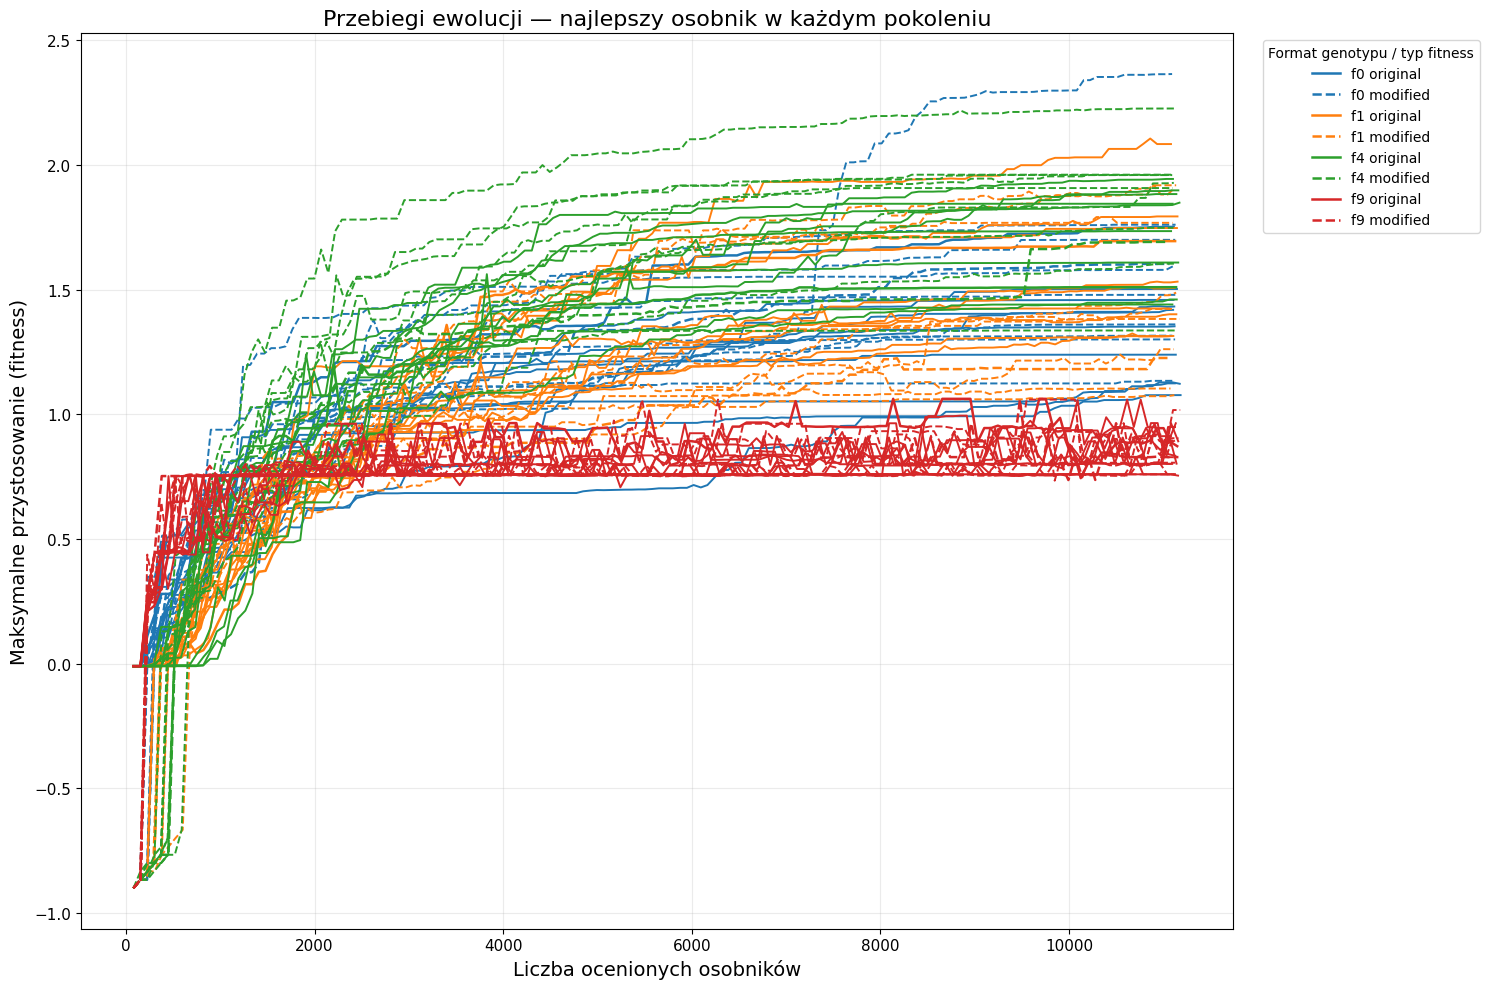

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("genotype_results.csv")

if "cumulative_nevals" not in df.columns:
    if "nevals" in df.columns:
        df["cumulative_nevals"] = df.groupby(["genotype_format", "iteration", "modified_fitness"])["nevals"].cumsum()
    else:
        raise KeyError("Neither 'cumulative_nevals' nor 'nevals' column found in CSV")

plt.figure(figsize=(15, 10), dpi=100)
genotypes = sorted(df["genotype_format"].unique())

palette = sns.color_palette("tab10")[:len(genotypes)]

for genotype, color in zip(genotypes, palette):
    iters = sorted(df[df["genotype_format"] == genotype]["iteration"].unique())
    for iteration in iters:
        for modified in [False, True]:
            df_temp = df[
                (df["genotype_format"] == genotype) & 
                (df["iteration"] == iteration) & 
                (df["modified_fitness"] == modified)
            ].sort_values("cumulative_nevals")
            if df_temp.empty:
                continue

            linestyle = '--' if modified else '-'
            
            label = f"{genotype} {'modified' if modified else 'original'}" if iteration == iters[0] else None
            
            plt.plot(
                df_temp["cumulative_nevals"], 
                df_temp["max"],
                label=label,
                color=color,
                linewidth=1.8 if iteration == iters[0] else 1.4,
                alpha=1.0,
                linestyle=linestyle
            )

plt.title("Przebiegi ewolucji — najlepszy osobnik w każdym pokoleniu", fontsize=16)
plt.xlabel("Liczba ocenionych osobników", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Format genotypu / typ fitness", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji.png", dpi=200)
plt.show()


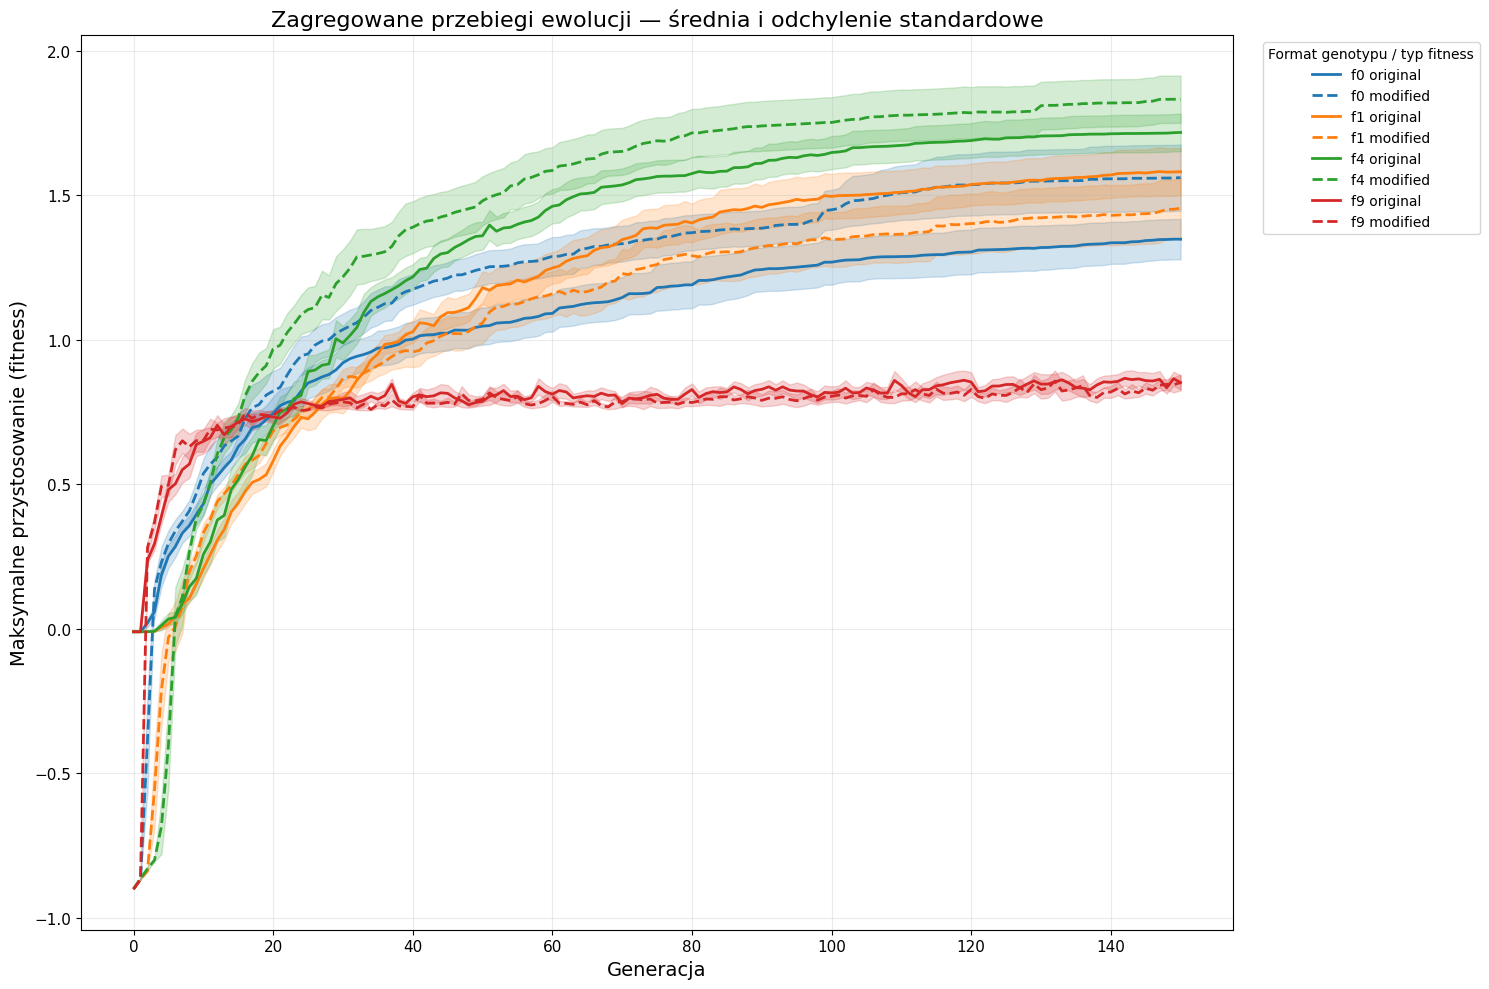

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("genotype_results.csv")

df_agg = df.groupby(["gen", "genotype_format", "modified_fitness"])["max"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(15, 10), dpi=100)
genotypes = sorted(df_agg["genotype_format"].unique())
palette = sns.color_palette("tab10")[:len(genotypes)]
SCALING_FACTOR = 3

for genotype, color in zip(genotypes, palette):
    for modified in [False, True]:
        df_temp = df_agg[(df_agg["genotype_format"] == genotype) & (df_agg["modified_fitness"] == modified)]
        if df_temp.empty:
            continue
        linestyle = '--' if modified else '-'
        label = f"{genotype} {'modified' if modified else 'original'}"
        plt.plot(df_temp["gen"], df_temp["mean"], label=label, color=color, linewidth=2, linestyle=linestyle)
        plt.fill_between(df_temp["gen"],
                         df_temp["mean"] - df_temp["std"] / SCALING_FACTOR,
                         df_temp["mean"] + df_temp["std"] / SCALING_FACTOR,
                         color=color, alpha=0.2)

plt.title("Zagregowane przebiegi ewolucji — średnia i odchylenie standardowe", fontsize=16)
plt.xlabel("Generacja", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Format genotypu / typ fitness", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji_zagregowane.png", dpi=200)
plt.show()


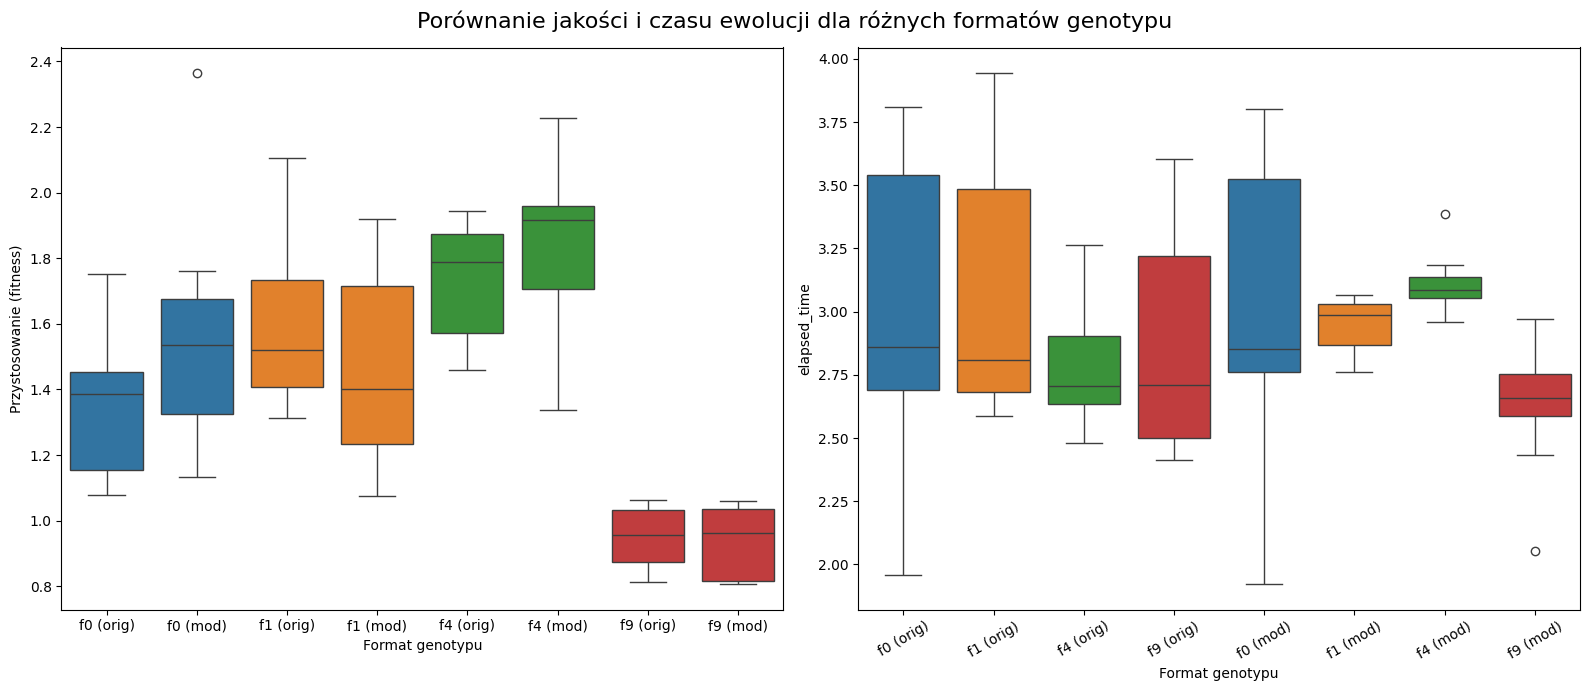

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

df = pd.read_csv("genotype_results.csv")

df_best = df.groupby(["genotype_format", "iteration", "modified_fitness"], as_index=False)["max"].max()
df_best = df_best[["genotype_format", "max", "modified_fitness"]]

df_times = pd.read_csv("genotype_times.csv", index_col=False)

if "elapsed_time" in df_times.columns:
    df_times["elapsed_time"] /= 60
    df_times = df_times.merge(df[["genotype_format", "iteration", "modified_fitness"]].drop_duplicates(),
                              on=["genotype_format", "iteration", "modified_fitness"], how="left")

df_best["genotype_format_str"] = df_best["genotype_format"] + df_best["modified_fitness"].map({False: " (orig)", True: " (mod)"})
if "genotype_format" in df_times.columns:
    df_times["genotype_format_str"] = df_times["genotype_format"] + df_times["modified_fitness"].map({False: " (orig)", True: " (mod)"})

genotypes_sorted = sorted(df["genotype_format"].unique())
palette_colors = sns.color_palette("tab10")[:len(genotypes_sorted)]

palette = {}
for i, g in enumerate(genotypes_sorted):
    orig_color = palette_colors[i]
    mod_color = mcolors.to_rgba(orig_color, alpha=0.5)
    palette[f"{g} (orig)"] = orig_color
    palette[f"{g} (mod)"] = mod_color

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

sns.boxplot(ax=axes[0], x="genotype_format_str", y="max", data=df_best,
            hue="genotype_format_str",
            palette=palette,
            dodge=False,
            legend=False)

if "elapsed_time" in df_times.columns:
    sns.boxplot(ax=axes[1], x="genotype_format_str", y="elapsed_time", data=df_times,
                hue="genotype_format_str",
                palette=palette,
                dodge=False,
                legend=False)
else:
    axes[1].set_visible(False)

axes[0].set_xlabel("Format genotypu")
axes[0].set_ylabel("Przystosowanie (fitness)")
axes[1].set_xlabel("Format genotypu")

plt.suptitle("Porównanie jakości i czasu ewolucji dla różnych formatów genotypu", fontsize=16)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("przebiegi_ewolucji_boxploty.png", dpi=200)
plt.show()


### Wyjaśnienie różnic przy funkcji celu bez modyfikacji

Przy zastosowaniu oryginalnej funkcji celu różnice między reprezentacjami są znacznie bardziej widoczne.  

Reprezentacja **f0** ma największe trudności z opuszczeniem plateau – przez wiele pokoleń nie osiąga zauważalnych postępów i wyraźnie odstaje od pozostałych formatów.  
W przypadku **f1** proces ewolucji przebiega stabilnie, jednak wyjście z plateau zajmuje więcej czasu. Mimo wolniejszego startu, populacja ta jest w stanie generować bardzo dobre rozwiązania w dalszej fazie eksperymentu.  
Format **f4** również radzi sobie dobrze – nawet bez modyfikacji osiąga wysokie wyniki i należy do najbardziej efektywnych reprezentacji.  
Z kolei **f9** poprawnie opuszcza plateau, ale końcowe wartości fitness są niższe niż w przypadku pozostałych formatów, co sugeruje, że reprezentacja ta nie potrafi w pełni wykorzystać mechanizmów ewolucyjnych.

Podsumowując, przy braku modyfikacji funkcji celu ewolucja jest mniej dynamiczna i mocno zależna od typu reprezentacji — tylko niektóre formaty, jak **f4**, potrafią konsekwentnie osiągać dobre wyniki.

---

### Opis i uzasadnienie modyfikacji funkcji celu
Moja zmodyfikowana funkcja celu działa następująco:

```python
parts_joints_ratio = numparts / numjoints if numjoints else 1
parts_joints_ratio = max(parts_joints_ratio, 1.5) # A cube has ratio 1.5
ratio_score = (1.5 - parts_joints_ratio) / 0.5  # best=1.5, smallest=1
ratio_score = max(ratio_score, 0)
if vertpos < 0:
    plateau_fitness = - 1 - ratio_score + numparts/max_numparts
    fitness = [plateau_fitness]
else:
    fitness = [vertpos]
```

Modyfikacja działa tylko w problematycznym fragmencie krajobrazu (`vertpos < 0`). W takiej sytuacji fitness jest zawsze ≤ 0, a osobniki z mniejszą liczbą części są oceniane lepiej (wartość bliższa zeru). Dzięki temu żaden osobnik oceniany w tej gałęzi nie osiąga przewagi nad osobnikami z dodatnim `vertpos`, ale jednocześnie wprowadza się gradient różnicujący w obrębie plateau.  
Uzasadnienie: złożone konstrukcje (z większą liczbą części i skomplikowanymi połączeniami) mają większe szanse na ewolucję ku dodatnim wartościom `vertpos`. Funkcja wymusza więc selekcję w kierunku większych i bardziej obiecujących struktur.

---

### Interpretacja rezultatów eksperymentu

Zastosowana modyfikacja przyniosła poprawę we wszystkich reprezentacjach poza **f1** i sprawiła, że dla każdego formatu plateau jest opuszczane szybciej:

- **f0**: największa zmiana – po modyfikacji wychodzi z plateau już w pierwszych generacjach i osiąga wyniki zbliżone do pozostałych formatów, z czym miała problem oryginalna funkcja.  
- **f1**: zdecydowanie szybciej opuszcza plateau, jednak powstała populacja nie jest w stanie później wygenerować tak dobrych rozwiązań jak przy oryginalnej funkcji. Prawdopodobnie wynika to z utraty różnorodności populacji.  
- **f4**: zmiana porównywalnej jakości jak w przypadku **f0**; jest to również zdecydowanie najlepszy format genetyczny, gdyż zarówno w wersji oryginalnej, jak i zmodyfikowanej osiąga najlepsze wyniki.  
- **f9**: poprawa jest najmniejsza, a już w wersji bazowej reprezentacja radziła sobie słabo. Może to oznaczać, że reprezentacja **f9** nie wykorzystuje w pełni możliwości algorytmu genetycznego.

Wyniki pokazują, że wprowadzenie gradientu na plateau nie tylko przyspieszyło ewolucję, ale też ułatwiło porównywalność reprezentacji.

---

### Jak jeszcze można pomóc ewolucji wyjść z plateau
Oprócz modyfikowania funkcji celu istnieją bardziej naturalne metody wspierania procesu:
- **Adaptacyjne tempo mutacji** – na początku większe, później malejące.
- **Utrzymywanie różnorodności populacji** – np. fitness sharing, island models.
- **Różnorodne populacje początkowe** – startowanie z wielu odmiennych genotypów (ale bez ręcznego ustawiania konkretnych rozwiązań).
- **Novelty search** – dodatkowy cel premiujący różnorodność fenotypów, nawet jeśli chwilowo nie zwiększa `vertpos`.

Takie mechanizmy, w przeciwieństwie do ręcznego „sterowania” funkcją celu, pozwalają bardziej naturalnie zwiększyć eksplorację przestrzeni rozwiązań.
